# Lab two report
## Iris classification with regression

### Name: Jim Li

In [129]:
# This cell import all the necessary packages
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_iris

## Prepare Data

In [130]:
# This cell load the iris dataset from scikit learn
iris = load_iris()

x_data = iris.data      # features:(150, 4)-> this line gives sepal length/width, petal length/width
y_data = iris.target    # targets: (150,) -> this line class labels 0 (setosa), 1 (versicolor), 2 (virginica)

print('x_data shape =',x_data.shape)
print('y_data shape =',y_data.shape)

x_data shape = (150, 4)
y_data shape = (150,)


In [131]:
# This cell normalize the features using standard  scaling so each feature has a mean 0 and standard deviation 1.
# This normalization helps the optimizer converge faster and keeps feature scales comparable.
x_mean = np.mean(x_data, axis=0)
x_std = np.std(x_data, axis=0)
x_scaled = (x_data - x_mean) / x_std

print("First five row of scaled x:")
print(x_scaled[:5])

First five row of scaled x:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [132]:
# This cell reshape the targets to a column vector (150, 1) so they match the shape of the network output, making things easier.
y_data = y_data.reshape(-1, 1)
print('reshaped y_data shape =', y_data.shape)

reshaped y_data shape = (150, 1)


In [133]:
# This cell convert the numpy arrays into PyTorch tensors (i used MSELoss here for float type).
inputs  = torch.from_numpy(x_scaled).float()
targets = torch.from_numpy(y_data).float()

print('inputs size  =', inputs.size())
print('targets size =', targets.size())

inputs size  = torch.Size([150, 4])
targets size = torch.Size([150, 1])


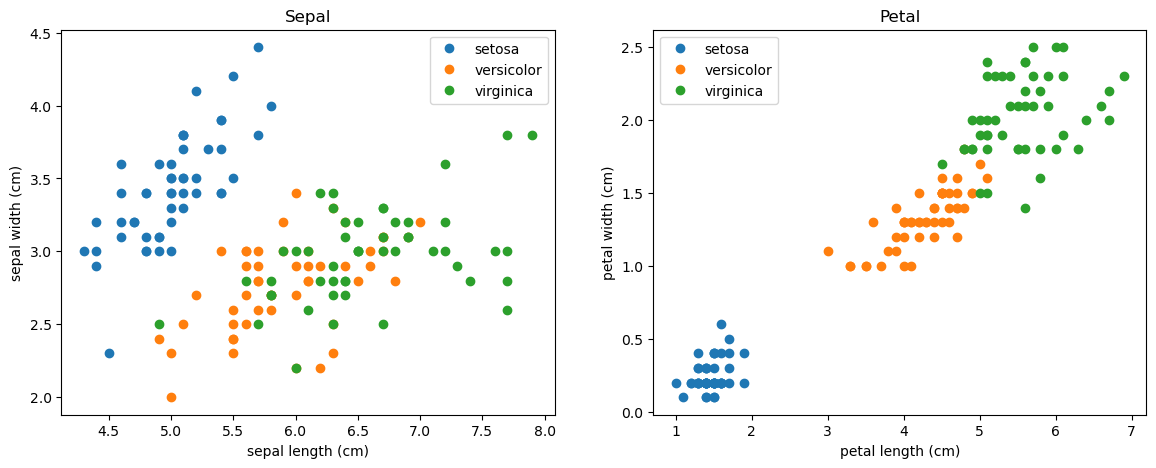

In [134]:
# i made a visualization of the dataset before training (helps me to see whether classes are separable).
feature_names = iris['feature_names']
names = iris['target_names']

fig, (plot_1, plot_2) = plt.subplots(1, 2, figsize=(14, 5))
for target, target_name in enumerate(names):
    X_plot = x_data[y_data.flatten() == target]
    plot_1.plot(X_plot[:, 0], X_plot[:, 1], 'o', label=target_name)
    plot_2.plot(X_plot[:, 2], X_plot[:, 3], 'o', label=target_name)
plot_1.set_xlabel(feature_names[0]); plot_1.set_ylabel(feature_names[1]); plot_1.legend(); plot_1.set_title('Sepal')
plot_2.set_xlabel(feature_names[2]); plot_2.set_ylabel(feature_names[3]); plot_2.legend(); plot_2.set_title('Petal')
plt.show()

## Define Model

In [135]:
# This cell build a class that include Neural network with one hidden layer of linear neurons
# Input  layer: 4 features (sepal length/width, petal length/width, which is what we had above)
# Hidden layer: chosen number of linear neurons
# Output layer:1 neuron whose value is rounded to 0, 1, or 2 for classification
class IrisRegression(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        # Initialize the parent nn.Module so we can use nn.Linear, .parameters(), etc.
        super(IrisRegression, self).__init__()
        self.layer1 = torch.nn.Linear(input_dim, hidden_dim)   # input  -> hidden
        self.layer2 = torch.nn.Linear(hidden_dim, output_dim)  # hidden -> output

    def forward(self, x):
        # this function describes the forward information flow from input to output.
        out = self.layer1(x)
        out = self.layer2(out)
        return out

## Select Hyperparameters

In [136]:
# This cell instantiate the model with 4 inputs, 8 hidden neurons, and 1 output.
input_dim, hidden_dim, output_dim = 4, 8, 1
model = IrisRegression(input_dim, hidden_dim, output_dim)

# Training hyperparameters (i chose 48<50 epochs for this assignment).
learning_rate = 0.1
epochs = 48

# since we treat class label as a continious target, then Mean-squared-error loss is appropriate
loss_func = torch.nn.MSELoss()
# SGD( stochastic gradient descent) updates weights at the pace of the learning rate
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

## Identify Tracked Values

In [137]:
# This cell empty list to record training loss after every epoch so we can plot it later.
train_loss_list = []

## Train Model

In [138]:
# I build a Standard PyTorch training loop for this cell
for epoch in range(epochs):
    optimizer.zero_grad()              # here it clears gradients so each epoch's update is independent
    outputs = model(inputs)            # forward pass: predict y from the features
    loss = loss_func(outputs, targets) # compute MSE between predictions and true labels
    train_loss_list.append(loss.item())# record loss for visualization
    loss.backward()                    # compute gradients using backward pass
    optimizer.step()                   #update weights and biases
    print('epoch {}, loss {}'.format(epoch, loss.item()))

epoch 0, loss 0.56792151927948
epoch 1, loss 0.16111229360103607
epoch 2, loss 0.08363470435142517
epoch 3, loss 0.06788651645183563
epoch 4, loss 0.06327657401561737
epoch 5, loss 0.061454467475414276
epoch 6, loss 0.06044188141822815
epoch 7, loss 0.05969614163041115
epoch 8, loss 0.0590599961578846
epoch 9, loss 0.058483224362134933
epoch 10, loss 0.05794709548354149
epoch 11, loss 0.05744325742125511
epoch 12, loss 0.056967247277498245
epoch 13, loss 0.056516289710998535
epoch 14, loss 0.05608848109841347
epoch 15, loss 0.05568227916955948
epoch 16, loss 0.055296458303928375
epoch 17, loss 0.0549299418926239
epoch 18, loss 0.05458169803023338
epoch 19, loss 0.054250817745923996
epoch 20, loss 0.053936462849378586
epoch 21, loss 0.05363776534795761
epoch 22, loss 0.053353969007730484
epoch 23, loss 0.053084343671798706
epoch 24, loss 0.052828192710876465
epoch 25, loss 0.05258481949567795
epoch 26, loss 0.05235360562801361
epoch 27, loss 0.052133940160274506
epoch 28, loss 0.0519252

## Visualize and Evaluate Model

In [139]:
# This cell run the trained model on the training data with disabled gradient tracking.
with torch.no_grad():
    predicted = model(inputs)

predicted_np = predicted.numpy()

# This cell round continuous predictions to the nearest integer class (0, 1, or 2).
predicted_round = np.round(predicted_np)
# This cell clip predictions that fall outside the valid label range.
predicted_round[predicted_round < 0] = 0
predicted_round[predicted_round > 2] = 2

In [140]:
# this cell compute training accuracy: (correct predictions) / (total samples)
correct = 0
for i in range(len(y_data)):
    if predicted_round[i][0] == y_data[i][0]:
        correct += 1
accuracy = correct / len(y_data)
print('Training accuracy =', accuracy)

Training accuracy = 0.96


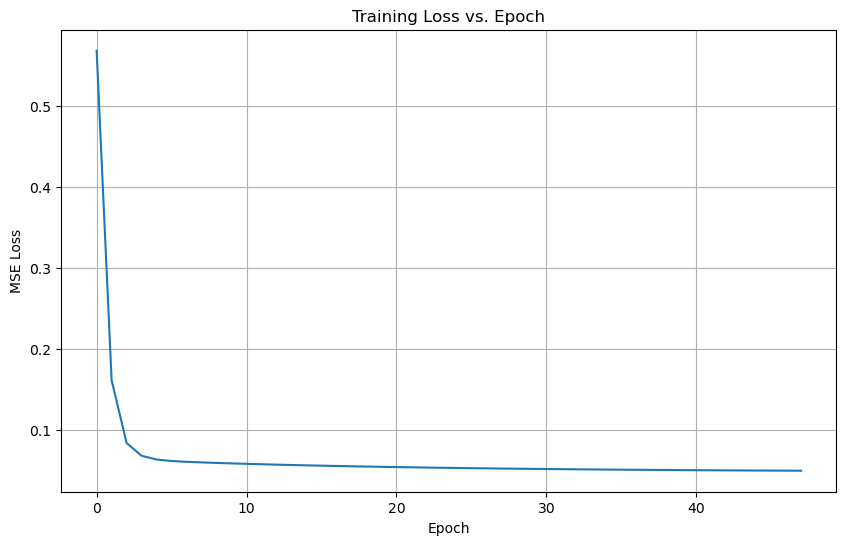

In [141]:
# final cell plot the training loss over epochs. A steadily decreasing curve means the model is learning.
plt.figure(figsize=(10, 6))
plt.plot(train_loss_list)
plt.title('Training Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid()
plt.show()